In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generamos datos sintéticos: ventas por mes
fechas = pd.date_range(start='2020-01-01', periods=36, freq='M')
ventas = np.random.randint(100, 500, size=36)

df = pd.DataFrame({
    'fecha': fechas,
    'ventas': ventas
})
df.head()


C:\Users\eulal\AppData\Local\Temp\ipykernel_21900\3669336847.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fechas = pd.date_range(start='2020-01-01', periods=36, freq='M')


,fecha,ventas
0,2020-01-31,125
1,2020-02-29,204
2,2020-03-31,322
3,2020-04-30,388
4,2020-05-31,101


Creacion de variable de tiempo

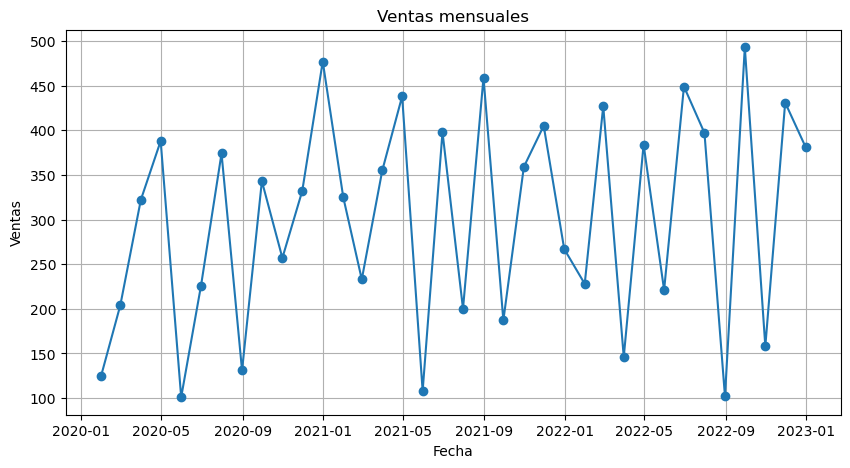

In [5]:
df['mes_num'] = np.arange(len(df))  # 0, 1, 2, ...
plt.figure(figsize=(10, 5))
plt.plot(df['fecha'], df['ventas'], marker='o')
plt.title('Ventas mensuales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()


Ajustamos el modelo

In [6]:
X = df[['mes_num']]
y = df['ventas']

modelo = LinearRegression()
modelo.fit(X, y)


LinearRegression()

Hacer predicciones y evaluamos

In [8]:
df['ventas_pred'] = modelo.predict(X)
mse = mean_squared_error(df['ventas'], df['ventas_pred'])
print(f'Error cuadrático medio: {mse:.2f}')


Error cuadrático medio: 13477.07


Predecir valores futuros

In [12]:

futuro = pd.DataFrame({
    'mes_num': np.arange(len(df), len(df) + 6)
})
futuro['ventas_pred'] = modelo.predict(futuro[['mes_num']])

# Generar fechas futuras
ultima_fecha = df['fecha'].max()
futuro['fecha'] = pd.date_range(start=ultima_fecha + pd.offsets.MonthBegin(), periods=6, freq='M')


C:\Users\eulal\AppData\Local\Temp\ipykernel_21900\1330088984.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  futuro['fecha'] = pd.date_range(start=ultima_fecha + pd.offsets.MonthBegin(), periods=6, freq='M')


Visualizacion


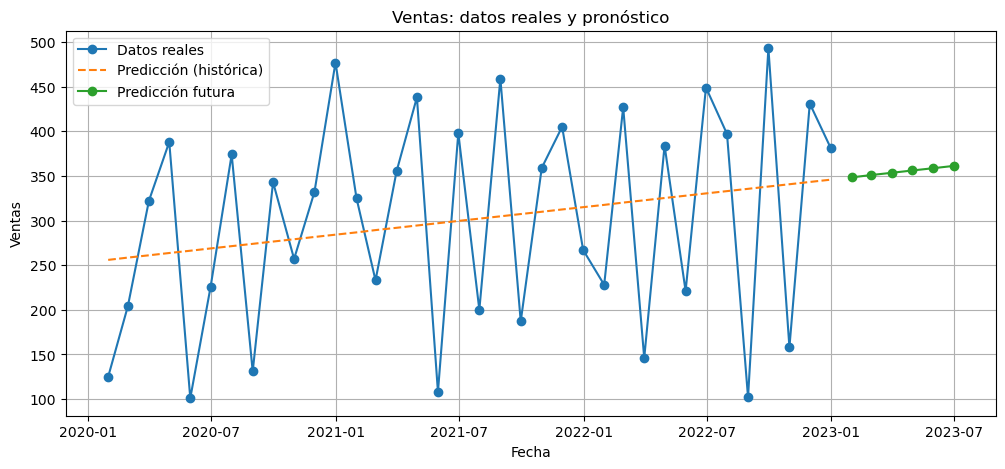

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(df['fecha'], df['ventas'], label='Datos reales', marker='o')
plt.plot(df['fecha'], df['ventas_pred'], label='Predicción (histórica)', linestyle='--')
plt.plot(futuro['fecha'], futuro['ventas_pred'], label='Predicción futura', marker='o')
plt.legend()
plt.title('Ventas: datos reales y pronóstico')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()
